<a href="https://colab.research.google.com/github/arunreghunath25b-afk/WNS_analytics_Arun-_Reghunath/blob/main/WNS_Analytics_Wizard_2018_Arun_Reghunath.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd


In [3]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier



In [4]:
train = pd.read_csv("/content/drive/MyDrive/DSA/Case study/train_LZdllcl.csv")
test = pd.read_csv("/content/drive/MyDrive/DSA/Case study/test_2umaH9m.csv")
sample = pd.read_csv("/content/drive/MyDrive/DSA/Case study/sample_submission_M0L0uXE.csv")



In [5]:
train.info()

train.head()

train.tail()

train.shape

train.isnull().sum()

train.duplicated().sum()

train["is_promoted"].value_counts()

train["is_promoted"].value_counts(normalize=True) * 100



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


,proportion
is_promoted,
0,91.482995
1,8.517005


In [6]:
X = train.drop("is_promoted", axis=1)
y = train["is_promoted"]

X = X.drop("employee_id", axis=1)
test_ids = test["employee_id"]

X_test = test.drop("employee_id", axis=1)

X["education"] = X["education"].fillna("Unknown")
X_test["education"] = X_test["education"].fillna("Unknown")

X["previous_year_rating"] = X["previous_year_rating"].fillna(
    X["previous_year_rating"].median()
)

X_test["previous_year_rating"] = X_test["previous_year_rating"].fillna(
    X["previous_year_rating"].median()
)

X.isnull().sum()



,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0
KPIs_met >80%,0


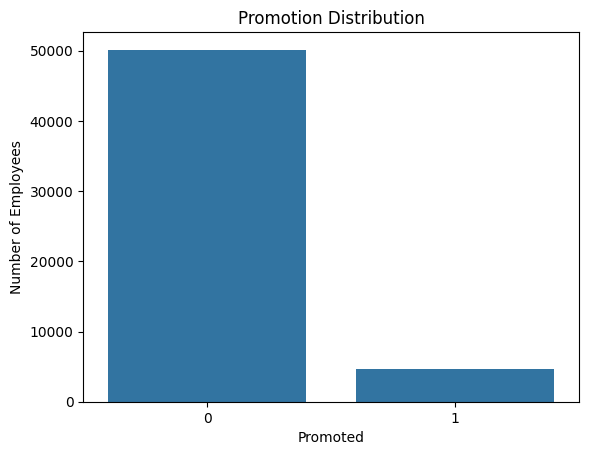

In [7]:
sns.countplot(x="is_promoted", data=train)

plt.title("Promotion Distribution")
plt.xlabel("Promoted")
plt.ylabel("Number of Employees")

plt.show()



In [8]:
plt.figure(figsize=(12, 5))



<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

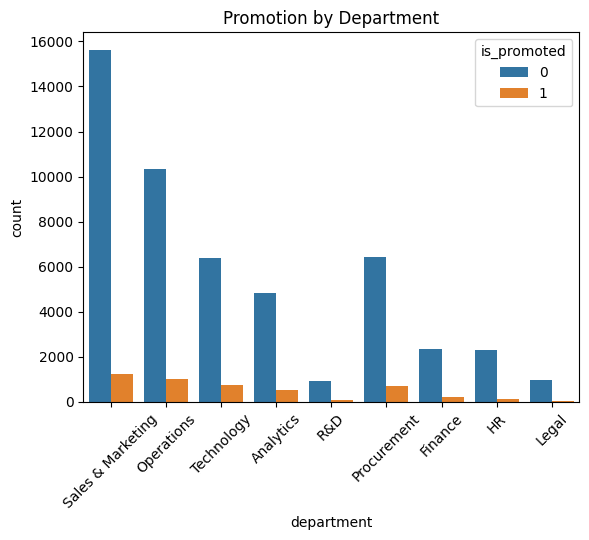

In [9]:
sns.countplot(
    data=train,
    x="department",
    hue="is_promoted"
)

plt.title("Promotion by Department")
plt.xticks(rotation=45)

plt.show()



In [10]:
plt.figure(figsize=(6, 5))



<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

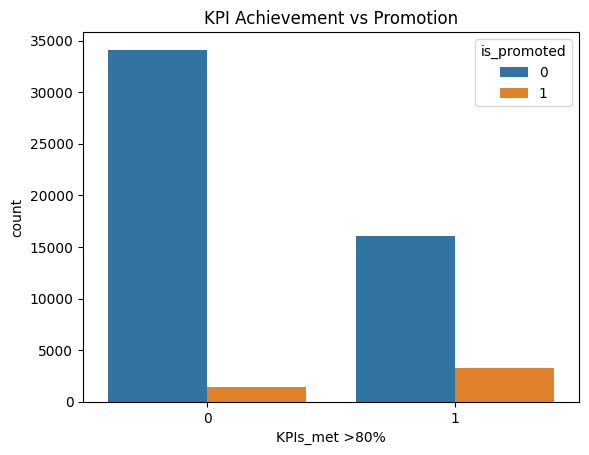

In [11]:
sns.countplot(
    data=train,
    x="KPIs_met >80%",
    hue="is_promoted"
)

plt.title("KPI Achievement vs Promotion")

plt.show()



In [12]:
plt.figure(figsize=(6, 5))



<Figure size 600x500 with 0 Axes>

<Figure size 600x500 with 0 Axes>

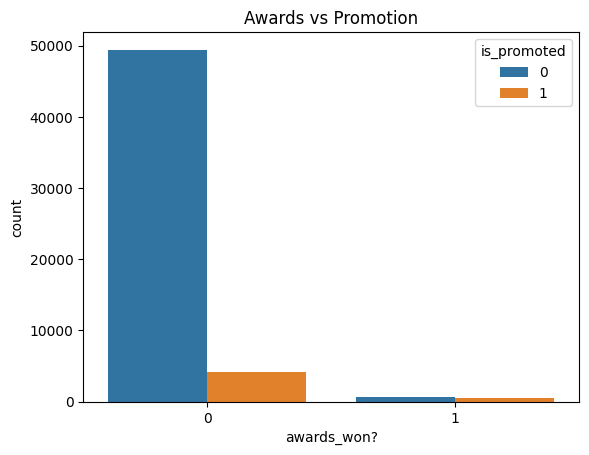

In [13]:
sns.countplot(
    data=train,
    x="awards_won?",
    hue="is_promoted"
)

plt.title("Awards vs Promotion")

plt.show()



In [14]:
plt.figure(figsize=(8, 5))



<Figure size 800x500 with 0 Axes>

<Figure size 800x500 with 0 Axes>

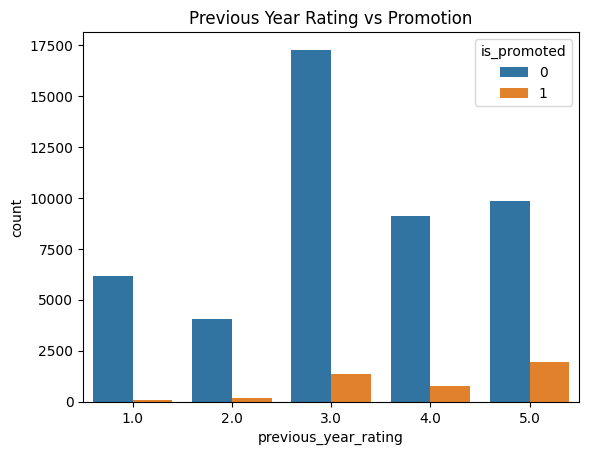

In [15]:
sns.countplot(
    data=train,
    x="previous_year_rating",
    hue="is_promoted"
)

plt.title("Previous Year Rating vs Promotion")

plt.show()



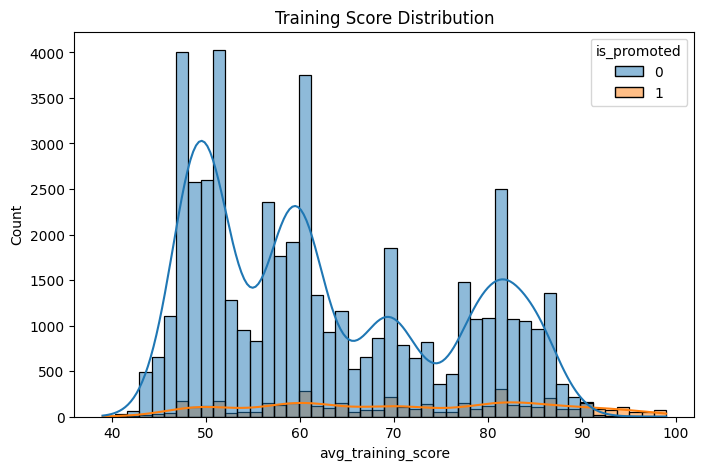

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=train,
    x="avg_training_score",
    hue="is_promoted",
    kde=True
)

plt.title("Training Score Distribution")

plt.show()



In [17]:
numeric_cols = [
    "no_of_trainings",
    "age",
    "previous_year_rating",
    "length_of_service",
    "KPIs_met >80%",
    "awards_won?",
    "avg_training_score",
    "is_promoted"
]



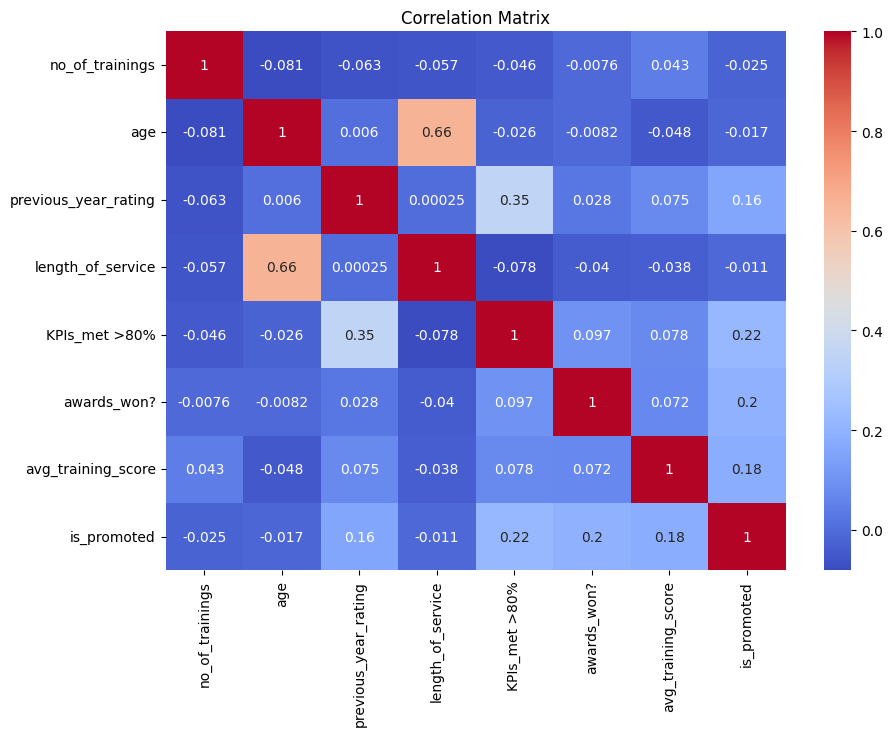

In [18]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    train[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()



In [19]:
categorical_columns = [
    "department",
    "region",
    "education",
    "gender",
    "recruitment_channel"
]



In [20]:
encoders = {}

for column in categorical_columns:

    encoder = LabelEncoder()

    X[column] = encoder.fit_transform(
        X[column].astype(str)
    )

    X_test[column] = encoder.transform(
        X_test[column].astype(str)
    )

    encoders[column] = encoder

X.head()



,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score
0,7,31,2,0,2,1,35,5.0,8,1,0,49
1,4,14,0,1,0,1,30,5.0,4,0,0,60
2,7,10,0,1,2,1,34,3.0,7,0,0,50
3,7,15,0,1,0,2,39,1.0,10,0,0,50
4,8,18,0,1,0,1,45,3.0,2,0,0,73


In [21]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", X_train.shape)
print("Validation:", X_valid.shape)



Training: (43846, 12)
Validation: (10962, 12)


              precision    recall  f1-score   support

           0       0.92      1.00      0.96     10028
           1       0.64      0.07      0.13       934

    accuracy                           0.92     10962
   macro avg       0.78      0.54      0.55     10962
weighted avg       0.90      0.92      0.89     10962

Logistic Regression F1: 0.1342281879194631


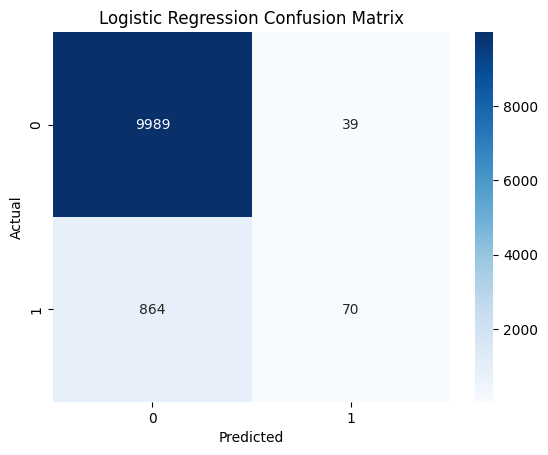

In [22]:
logistic_model = LogisticRegression(
    max_iter=1000
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_prediction = logistic_model.predict(
    X_valid
)

print(
    classification_report(
        y_valid,
        logistic_prediction
    )
)

logistic_f1 = f1_score(
    y_valid,
    logistic_prediction
)

print("Logistic Regression F1:", logistic_f1)

cm = confusion_matrix(
    y_valid,
    logistic_prediction
)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")

plt.show()



In [23]:
decision_tree = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

decision_tree.fit(
    X_train,
    y_train
)

tree_prediction = decision_tree.predict(
    X_valid
)

print(
    classification_report(
        y_valid,
        tree_prediction
    )
)

tree_f1 = f1_score(
    y_valid,
    tree_prediction
)

print("Decision Tree F1:", tree_f1)



              precision    recall  f1-score   support

           0       0.93      1.00      0.96     10028
           1       0.84      0.17      0.28       934

    accuracy                           0.93     10962
   macro avg       0.88      0.58      0.62     10962
weighted avg       0.92      0.93      0.90     10962

Decision Tree F1: 0.280107047279215


In [24]:
random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

random_forest.fit(
    X_train,
    y_train
)

rf_prediction = random_forest.predict(
    X_valid
)

print(
    classification_report(
        y_valid,
        rf_prediction
    )
)

rf_f1 = f1_score(
    y_valid,
    rf_prediction
)

print("Random Forest F1:", rf_f1)



              precision    recall  f1-score   support

           0       0.93      1.00      0.96     10028
           1       0.94      0.16      0.27       934

    accuracy                           0.93     10962
   macro avg       0.93      0.58      0.62     10962
weighted avg       0.93      0.93      0.90     10962

Random Forest F1: 0.27131072410632445


In [25]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "F1 Score": [
        logistic_f1,
        tree_f1,
        rf_f1
    ]
})

model_results.sort_values(
    "F1 Score",
    ascending=False
)



,Model,F1 Score
1,Decision Tree,0.280107
2,Random Forest,0.271311
0,Logistic Regression,0.134228


In [26]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

param_grid = {
    "max_depth": [3, 5, 7, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 8],
    "class_weight": [None, "balanced"]
}

grid_dt = GridSearchCV(
    dt,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_

dt_pred = best_dt.predict(X_valid)

print("Best Parameters:", grid_dt.best_params_)
print("Best CV F1:", grid_dt.best_score_)
print("Validation F1:", f1_score(y_valid, dt_pred))



Best Parameters: {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
Best CV F1: 0.4650350177785262
Validation F1: 0.47


In [27]:
from sklearn.model_selection import RandomizedSearchCV

rf_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [8, 12, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=1
)

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=30,
    scoring="f1",
    cv=3,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_rf.fit(X_train, y_train)

best_rf = random_rf.best_estimator_

rf_pred = best_rf.predict(X_valid)

print("Best Parameters:", random_rf.best_params_)
print("Best CV F1:", random_rf.best_score_)
print("Validation F1:", f1_score(y_valid, rf_pred))



Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_depth': None, 'class_weight': 'balanced'}
Best CV F1: 0.4520857198298793
Validation F1: 0.4617691154422789


In [28]:
import numpy as np
from sklearn.metrics import f1_score

dt_prob = best_dt.predict_proba(X_valid)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

threshold_results = []

for threshold in thresholds:
    prediction = (dt_prob >= threshold).astype(int)
    score = f1_score(y_valid, prediction)

    threshold_results.append({
        "Threshold": threshold,
        "F1 Score": score
    })

threshold_df = pd.DataFrame(threshold_results)

best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

print("Best Threshold:", best_threshold_row["Threshold"])
print("Best F1:", best_threshold_row["F1 Score"])



Best Threshold: 0.3699999999999999
Best F1: 0.4790575916230366


In [29]:
rf_prob = best_rf.predict_proba(X_valid)[:, 1]

thresholds = np.arange(0.10, 0.91, 0.01)

rf_threshold_results = []

for threshold in thresholds:
    prediction = (rf_prob >= threshold).astype(int)
    score = f1_score(y_valid, prediction)

    rf_threshold_results.append({
        "Threshold": threshold,
        "F1 Score": score
    })

rf_threshold_df = pd.DataFrame(rf_threshold_results)

best_rf_threshold_row = rf_threshold_df.loc[
    rf_threshold_df["F1 Score"].idxmax()
]

print("Best RF Threshold:", best_rf_threshold_row["Threshold"])
print("Best RF F1:", best_rf_threshold_row["F1 Score"])



Best RF Threshold: 0.5399999999999998
Best RF F1: 0.4699828473413379


In [30]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Use the thresholds found during threshold tuning
best_dt_threshold = best_threshold_row["Threshold"]
best_rf_threshold = best_rf_threshold_row["Threshold"]

# Decision Tree predictions using its best threshold
dt_final_pred = (
    best_dt.predict_proba(X_valid)[:, 1] >= best_dt_threshold
).astype(int)

# Random Forest predictions using its best threshold
rf_final_pred = (
    best_rf.predict_proba(X_valid)[:, 1] >= best_rf_threshold
).astype(int)

print("DECISION TREE")
print("Best Threshold:", best_dt_threshold)
print("Precision:", precision_score(y_valid, dt_final_pred))
print("Recall:", recall_score(y_valid, dt_final_pred))
print("F1:", f1_score(y_valid, dt_final_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_valid, dt_final_pred))

print("\nRANDOM FOREST")
print("Best Threshold:", best_rf_threshold)
print("Precision:", precision_score(y_valid, rf_final_pred))
print("Recall:", recall_score(y_valid, rf_final_pred))
print("F1:", f1_score(y_valid, rf_final_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_valid, rf_final_pred))

# Select the best tuned model based on validation F1
dt_validation_f1 = f1_score(y_valid, dt_final_pred)
rf_validation_f1 = f1_score(y_valid, rf_final_pred)

if dt_validation_f1 >= rf_validation_f1:
    final_model = best_dt
    final_threshold = best_dt_threshold
    final_model_name = "Decision Tree"
else:
    final_model = best_rf
    final_threshold = best_rf_threshold
    final_model_name = "Random Forest"

print("\nFINAL MODEL:", final_model_name)
print("FINAL THRESHOLD:", final_threshold)
print("FINAL VALIDATION F1:", max(dt_validation_f1, rf_validation_f1))

# Retrain the selected best model on the complete training dataset
final_model.fit(X, y)

# Predict the competition test dataset
test_probability = final_model.predict_proba(X_test)[:, 1]

test_prediction = (
    test_probability >= final_threshold
).astype(int)



DECISION TREE
Best Threshold: 0.3699999999999999
Precision: 0.6161616161616161
Recall: 0.39186295503211993
F1: 0.4790575916230366
Confusion Matrix:
[[9800  228]
 [ 568  366]]

RANDOM FOREST
Best Threshold: 0.5399999999999998
Precision: 0.5042944785276073
Recall: 0.4400428265524625
F1: 0.4699828473413379
Confusion Matrix:
[[9624  404]
 [ 523  411]]

FINAL MODEL: Decision Tree
FINAL THRESHOLD: 0.3699999999999999
FINAL VALIDATION F1: 0.4790575916230366


In [31]:
submission = pd.DataFrame({
    "employee_id": test["employee_id"],
    "is_promoted": test_prediction
})

print(submission.head())
print(submission["is_promoted"].value_counts())

print(submission.shape)
print(submission.columns)

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")
print("Final model used:", final_model_name)
print("Final threshold used:", final_threshold)

from google.colab import files

files.download("submission.csv")


   employee_id  is_promoted
0         8724            0
1        74430            0
2        72255            0
3        38562            0
4        64486            0
is_promoted
0    22347
1     1143
Name: count, dtype: int64
(23490, 2)
Index(['employee_id', 'is_promoted'], dtype='object')
submission.csv created successfully!
Final model used: Decision Tree
Final threshold used: 0.3699999999999999


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>